In [4]:
import tensorflow as tf
print(tf.__version__)


2.19.0


Flow Summary



```
Load Dataset
      ↓
Drop Unnecessary Columns
      ↓
Encoding
      ↓
Train-Test Split
      ↓
Feature Scaling
      ↓
Build ANN
      ↓
Compile Model
      ↓
Train Model
      ↓
Prediction
      ↓
Evaluation
```

# New section

#  Step 1: Import Libraries


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Step 2: Load Dataset and Check dataset

In [6]:
df = pd.read_csv('Churn_Modelling.csv')
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [36]:
df.isnull().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


# Step 3: Features aur Target Separate

In [7]:
#Divide the dataset into independent and dependent features

X = df.iloc[:,3:13]
y = df.iloc[:,13]

#OR

# X =df.drop(columns=['RowNumber','CustomerId','Surname'])
# y = df['Exited']

In [8]:
X.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,502,France,Female,42,8,159660.80,3,1,0,113931.57
3,699,France,Female,39,1,0.00,2,0,0,93826.63
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10


In [9]:
y

,Exited
0,1
1,0
2,1
3,0
4,0
...,...
9995,0
9996,0
9997,1
9998,1


# Step 4: Encode Target


In [16]:
#Create dummy variables
geography = pd.get_dummies(X['Geography'],drop_first=True,dtype=int)
gender = pd.get_dummies(X['Gender'],drop_first=True, dtype=int)


In [15]:
geography.head()

,Germany,Spain
0,0,0
1,0,1
2,0,0
3,0,0
4,0,1


In [17]:
## Concatenate the Data Frames

X=pd.concat([X,geography,gender],axis=1)

## Drop Unnecessary columns
X=X.drop(['Geography','Gender'],axis=1)





Step 5: Train-Test Split

In [37]:
 # Splitting the dataset into the Training set and Test set
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

Step 6: Feature Scaling

In [38]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


Step 7: Create ANN Model

In [ ]:
# Part 2 - Now let's make the ANN!

In [57]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Input, Dense

In [58]:
model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(11, activation='relu'),
    Dense(6, activation='relu'),
    Dense(1, activation='sigmoid')
])

Step 8: Compile Model

In [46]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

Step 9: Train Model

In [47]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.33
)


Epoch 1/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.6221 - loss: 0.6474 - val_accuracy: 0.7864 - val_loss: 0.5058
Epoch 2/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7953 - loss: 0.4674 - val_accuracy: 0.7959 - val_loss: 0.4531
Epoch 3/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8000 - loss: 0.4358 - val_accuracy: 0.8046 - val_loss: 0.4348
Epoch 4/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8196 - loss: 0.4165 - val_accuracy: 0.8205 - val_loss: 0.4190
Epoch 5/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8360 - loss: 0.3994 - val_accuracy: 0.8270 - val_loss: 0.4063
Epoch 6/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8444 - loss: 0.3858 - val_accuracy: 0.8289 - val_loss: 0.3962
Epoch 7/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8505 - loss: 0.3745 - val_accuracy: 0.8402 - val_loss: 0.3858
Epoch 8/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8513 - loss: 0.3659 - val_accuracy: 0

In [49]:
 # list all data in history

print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


Step 10. Model Summary

In [60]:
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 6)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 1)              │             7 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 211 (844.00 B)

 Trainable params: 211 (844.00 B)

 Non-trainable params: 0 (0.00 B)

Step 11. Prediction

In [61]:
# Part 3 - Making the predictions and evaluating the model

# Predicting the Test set results
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


Step 12. Accuracy

In [62]:
from sklearn.metrics import accuracy_score

score = accuracy_score(y_test, y_pred)
score

0.7985

Step 13. Confusion Matrix

In [63]:
# Making the Confusion Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
cm

array([[1594,    1],
       [ 402,    3]])

0.8605

Step 14. Classification Report

In [64]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      1.00      0.89      1595
           1       0.75      0.01      0.01       405

    accuracy                           0.80      2000
   macro avg       0.77      0.50      0.45      2000
weighted avg       0.79      0.80      0.71      2000



Step 15. Plot Accuracy

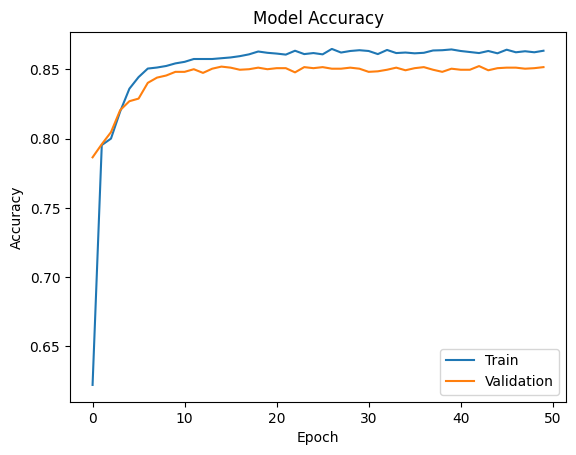

In [65]:
# summarize history for accuracy
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(['Train','Validation'])

plt.show()

Step 16. Plot Loss

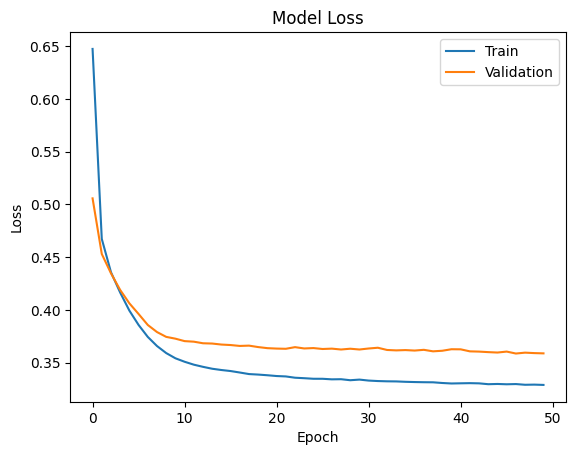

In [66]:
# summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(['Train','Validation'])
